# Лабораторная работа №2

## Часть A — Domain shift / распределения
1) Выберите датасет на русском  языке и два домена (2 темы из одного датасета, или 2 датасета HF, или свои тексты. Вариант датасета: https://huggingface.co/datasets/data-silence/rus_news_classifier).
2) Посчитайте **top-30 log-odds** токенов (в обе стороны).
3) Нарисуйте хотя бы 2 графика распределений (на выбор):
   - длина документов,
   - Zipf (частоты топ-100 токенов),
   - доля чисел/пунктуации,
   - размер словаря.
4) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
5) Напишите 5–10 наблюдений: что изменилось и почему.

## Часть B — Наивный Байес + оценка
1) Выберите 2 автора (русский).
2) Нарежьте тексты на чанки (80–300 токенов).
3) Обучите MultinomialNB и отчитайтесь:
   - confusion matrix,
   - precision/recall/F1.
4) Покажите **top-20 важнейших токенов** на основе Δ(w).
5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.



## Решение

- **Часть A:** датасет `data-silence/rus_news_classifier`, домены `politics` и `sports`;
- **Часть B:** **А. П. Чехов** и **Н. В. Гоголь**, обучение на **прозе**, затем domain shift на **пьесы**.



In [4]:
import re
from collections import Counter
from functools import lru_cache
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from bs4 import BeautifulSoup
from datasets import load_dataset
from pymorphy3 import MorphAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

NEWS_LABELS = {
    0: 'climate',
    1: 'conflicts',
    2: 'culture',
    3: 'economy',
    4: 'gloss',
    5: 'health',
    6: 'politics',
    7: 'science',
    8: 'society',
    9: 'sports',
    10: 'travel',
}

TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?|\d+|[^\w\s]", re.U)
WORD_RE = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?", re.U)

RU_STOPWORDS = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да',
    'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет',
    'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был',
    'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может',
    'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без',
    'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого',
    'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'кажется', 'сейчас',
    'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после',
    'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя',
    'впрочем', 'хорошо', 'свою', 'этой', 'перед', 'иногда', 'лучше', 'чуть', 'том', 'нельзя', 'такой', 'им', 'более',
    'всегда', 'конечно', 'всю', 'между'
}

morph = MorphAnalyzer()


In [5]:
def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

def word_tokens(text: str):
    return WORD_RE.findall(text.lower())

@lru_cache(maxsize=200_000)
def lemma(token: str) -> str:
    return morph.parse(token)[0].normal_form

def preprocess_tokens(text: str, lemmatize=False, drop_stopwords=False, ngram_range=(1, 1)):
    tokens = word_tokens(text)
    if lemmatize:
        tokens = [lemma(t) for t in tokens]
    if drop_stopwords:
        tokens = [t for t in tokens if t not in RU_STOPWORDS]

    features = list(tokens)
    for n in range(max(2, ngram_range[0]), ngram_range[1] + 1):
        features.extend([' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
    return features

def log_odds_df(counter_a: Counter, counter_b: Counter, alpha: float = 0.5) -> pd.DataFrame:
    vocab = sorted(set(counter_a) | set(counter_b))
    n_a = sum(counter_a.values())
    n_b = sum(counter_b.values())
    V = len(vocab)

    rows = []
    for token in vocab:
        p_a = (counter_a[token] + alpha) / (n_a + alpha * V)
        p_b = (counter_b[token] + alpha) / (n_b + alpha * V)
        rows.append((token, np.log(p_a / p_b)))

    return pd.DataFrame(rows, columns=['token', 'log_odds']).sort_values('log_odds', ascending=False)

def top_log_odds(counter_a: Counter, counter_b: Counter, left_name: str, right_name: str, top_n: int = 30):
    df = log_odds_df(counter_a, counter_b)
    left = df.head(top_n).reset_index(drop=True)
    right = df.tail(top_n).sort_values('log_odds').reset_index(drop=True)
    print(f'Top-{top_n} для {left_name}:')
    display(left)
    print(f'Top-{top_n} для {right_name}:')
    display(right)
    return left, right

def zipf_frame(texts):
    cnt = Counter(token for text in texts for token in word_tokens(text))
    items = cnt.most_common(100)
    return pd.DataFrame({
        'rank': np.arange(1, len(items) + 1),
        'token': [w for w, _ in items],
        'freq': [c for _, c in items],
    })

def corpus_stats(texts, label):
    tokenized = [tokenize(text) for text in texts]
    words = [word_tokens(text) for text in texts]
    vocab = {token for doc in words for token in doc}
    return {
        'domain': label,
        'docs': len(texts),
        'mean_len': np.mean([len(doc) for doc in words]),
        'median_len': np.median([len(doc) for doc in words]),
        'share_numbers': np.mean([sum(tok.isdigit() for tok in doc) / len(doc) for doc in tokenized]),
        'share_punct': np.mean([sum(len(tok) == 1 and not tok.isalnum() for tok in doc) / len(doc) for doc in tokenized]),
        'vocab_size': len(vocab),
    }

def extract_main_text(url: str) -> str:
    html = requests.get(url, timeout=30).text
    soup = BeautifulSoup(html, 'html.parser')

    candidates = []
    for tag in soup.find_all(['div', 'td', 'p']):
        text = ' '.join(tag.get_text(' ', strip=True).split())
        if len(text) > 500:
            candidates.append(text)

    text = max(candidates, key=len) if candidates else ' '.join(soup.get_text(' ', strip=True).split())
    text = re.sub(r'©\s*Это произведение перешло.*$', ' ', text)
    text = re.sub(r'^Авторы\s+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def load_ilibrary_work(index_url: str, cleanup_patterns=()):
    html = requests.get(index_url, timeout=30).text
    soup = BeautifulSoup(html, 'html.parser')

    page_links = []
    for a in soup.find_all('a', href=True):
        href = a['href']
        title = ' '.join(a.get_text(' ', strip=True).split())
        if '/text/' in href and title and title != '»':
            page_url = urljoin('https://ilibrary.ru', href)
            if page_url not in page_links:
                page_links.append(page_url)

    pages = [extract_main_text(url) for url in page_links]
    text = '\n'.join(dict.fromkeys(pages))

    for pattern in cleanup_patterns:
        text = re.sub(pattern, ' ', text, flags=re.I)

    text = re.sub(r'\s+', ' ', text)
    return text.strip(), page_links

def chunk_text(text: str, chunk_size: int = 160):
    tokens = word_tokens(text)
    return [' '.join(tokens[i:i + chunk_size]) for i in range(0, len(tokens) - chunk_size + 1, chunk_size)]

def fit_nb(chunks_train, y_train, chunks_test, y_test, *, preprocessor=None, alpha=1.0, token_pattern=r'(?u)\b[а-яё]{2,}\b', min_df=2):
    if preprocessor is not None:
        chunks_train = [' '.join(preprocessor(text)) for text in chunks_train]
        chunks_test = [' '.join(preprocessor(text)) for text in chunks_test]
        token_pattern = r'(?u)\b[^\s]+\b'

    vectorizer = CountVectorizer(token_pattern=token_pattern, min_df=min_df)
    X_train = vectorizer.fit_transform(chunks_train)
    X_test = vectorizer.transform(chunks_test)

    clf = MultinomialNB(alpha=alpha)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        'vectorizer': vectorizer,
        'clf': clf,
        'y_pred': y_pred,
        'report': classification_report(y_test, y_pred, output_dict=True, digits=3),
        'cm': confusion_matrix(y_test, y_pred, labels=clf.classes_),
    }

def important_tokens(model, positive_class: str, top_n: int = 20):
    vectorizer = model['vectorizer']
    clf = model['clf']
    classes = list(clf.classes_)
    feat_names = np.array(vectorizer.get_feature_names_out())
    pos_idx = classes.index(positive_class)
    neg_idx = 1 - pos_idx
    delta = clf.feature_log_prob_[pos_idx] - clf.feature_log_prob_[neg_idx]
    df = pd.DataFrame({'token': feat_names, 'delta': delta}).sort_values('delta', ascending=False)
    return df.head(top_n).reset_index(drop=True), df.tail(top_n).sort_values('delta').reset_index(drop=True)


### Часть A. Domain shift / распределения

Для части A беру `data-silence/rus_news_classifier` и сравниваю два домена из одного корпуса: **politics** и **sports**. Чтобы расчеты были быстрее, беру по 2500 новостей на домен.


In [6]:
news_train = load_dataset('data-silence/rus_news_classifier', split='train').to_pandas()
news_train['label_name'] = news_train['labels'].map(NEWS_LABELS)

domains = ['politics', 'sports']
news_subset = (
    news_train[news_train['label_name'].isin(domains)]
    .groupby('label_name', group_keys=False)
    .head(2500)
    .reset_index(drop=True)
)

texts_politics = news_subset.loc[news_subset['label_name'] == 'politics', 'news'].tolist()
texts_sports = news_subset.loc[news_subset['label_name'] == 'sports', 'news'].tolist()

print(news_subset['label_name'].value_counts())
display(pd.DataFrame([corpus_stats(texts_politics, 'politics'), corpus_stats(texts_sports, 'sports')]))


label_name
sports      2500
politics    2500
Name: count, dtype: int64


,domain,docs,mean_len,median_len,share_numbers,share_punct,vocab_size
0,politics,2500,151.5512,133.0,0.016170,0.165064,42939
1,sports,2500,126.9488,122.0,0.032564,0.182841,31872


In [7]:
politics_counter = Counter(token for text in texts_politics for token in word_tokens(text))
sports_counter = Counter(token for text in texts_sports for token in word_tokens(text))

log_odds_raw_politics, log_odds_raw_sports = top_log_odds(
    politics_counter,
    sports_counter,
    left_name='politics',
    right_name='sports',
    top_n=30,
)


Top-30 для politics:


,token,log_odds
0,навального,6.796404
1,навальный,5.912352
2,киеву,5.645148
3,всу,5.559501
4,дипломат,5.416736
5,фбк,5.378269
6,зеленского,5.305066
7,республик,5.179340
8,глав,5.120210
9,поток,5.089279


Top-30 для sports:


,token,log_odds
0,сборной,-7.405077
1,нхл,-7.230314
2,мок,-7.118587
3,спортсмен,-7.071749
4,спортсменов,-7.045432
5,матче,-6.930337
6,хоккейной,-6.868633
7,турнире,-6.866182
8,чемпион,-6.709780
9,матч,-6.659769


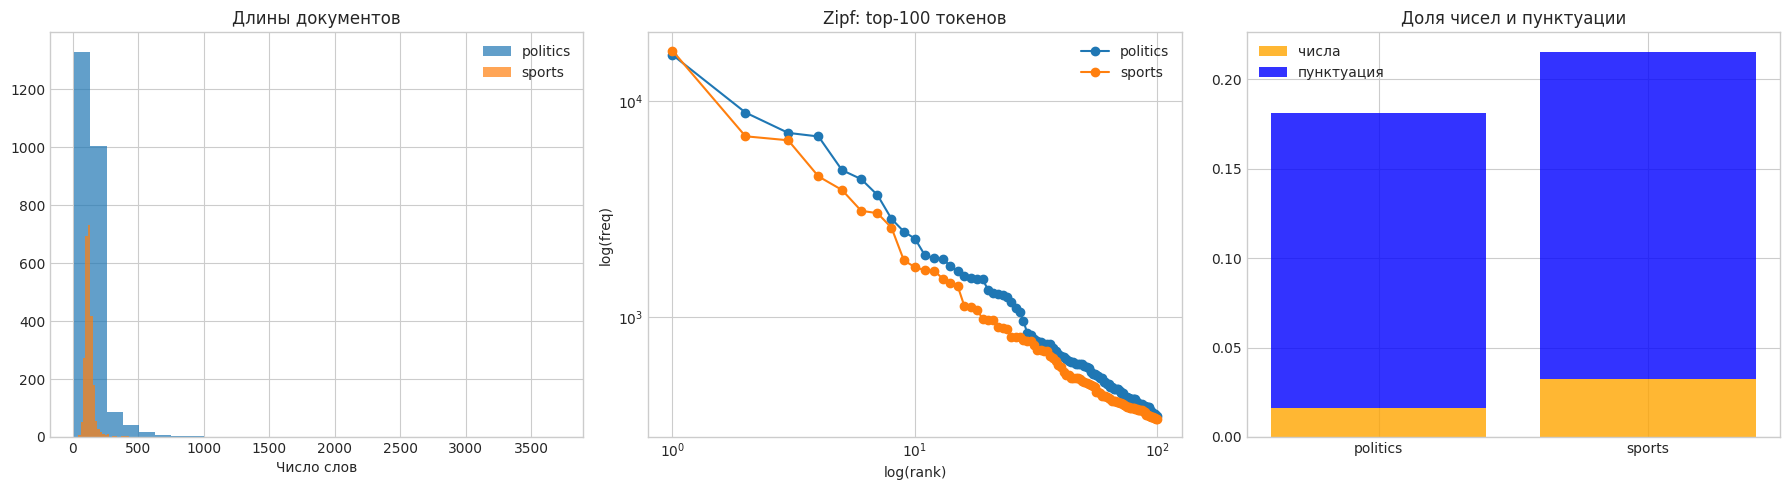

In [ ]:
zipf_politics = zipf_frame(texts_politics)
zipf_sports = zipf_frame(texts_sports)

len_politics = [len(word_tokens(text)) for text in texts_politics]
len_sports = [len(word_tokens(text)) for text in texts_sports]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(len_politics, bins=30, alpha=0.7, label='politics')
axes[0].hist(len_sports, bins=30, alpha=0.7, label='sports')
axes[0].set_title('Длины документов')
axes[0].set_xlabel('Число слов')
axes[0].legend()

axes[1].plot(zipf_politics['rank'], zipf_politics['freq'], marker='o', label='politics')
axes[1].plot(zipf_sports['rank'], zipf_sports['freq'], marker='o', label='sports')
axes[1].set_xscale('log')
axes[1].set_yscale('log')s
axes[1].set_title('Zipf: top-100 токенов')
axes[1].set_xlabel('log(rank)')
axes[1].set_ylabel('log(freq)')
axes[1].legend()

plot_df = pd.DataFrame([corpus_stats(texts_politics, 'politics'), corpus_stats(texts_sports, 'sports')])
axes[2].bar(plot_df['domain'], plot_df['share_numbers'], alpha=0.8, label='числа', color='orange')
axes[2].bar(plot_df['domain'], plot_df['share_punct'], alpha=0.8, label='пунктуация', color='blue', bottom=plot_df['share_numbers'])
axes[2].set_title('Доля чисел и пунктуации')
axes[2].legend()

plt.tight_layout()
plt.show()


In [9]:
politics_counter_proc = Counter(
    token
    for text in texts_politics
    for token in preprocess_tokens(text, lemmatize=True, drop_stopwords=True, ngram_range=(1, 2))
)

sports_counter_proc = Counter(
    token
    for text in texts_sports
    for token in preprocess_tokens(text, lemmatize=True, drop_stopwords=True, ngram_range=(1, 2))
)

log_odds_proc_politics, log_odds_proc_sports = top_log_odds(
    politics_counter_proc,
    sports_counter_proc,
    left_name='politics (леммы + без стоп-слов + 1-2 граммы)',
    right_name='sports (леммы + без стоп-слов + 1-2 граммы)',
    top_n=30,
)


Top-30 для politics (леммы + без стоп-слов + 1-2 граммы):


,token,log_odds
0,навальный,7.320136
1,алексей навальный,6.435298
2,вооружение,5.787148
3,поток,5.587069
4,всу,5.582717
5,обстрел,5.560665
6,боеприпас,5.454933
7,белый дом,5.439951
8,оппозиционер,5.432376
9,северный поток,5.424742


Top-30 для sports (леммы + без стоп-слов + 1-2 граммы):


,token,log_odds
0,сборная,-7.930061
1,нхл,-7.207098
2,сборная россия,-7.205392
3,мокнуть,-7.095371
4,хоккейный,-6.976038
5,турнир,-6.957244
6,хоккейный лига,-6.867210
7,фигуристка,-6.779654
8,кубок,-6.779654
9,валиев,-6.771780


### Наблюдения по части A

1. В исходных unigram-списках домены разделяются очень резко: у `politics` наверх выходят `навальный`, `всу`, `зеленского`, а у `sports` — `сборной`, `нхл`, `матч`, `олимпийский`.
2. Политические новости в среднем длиннее спортивных: в моем сэмпле средняя длина была примерно **152 слова** против **127**. Это ожидаемо: политика чаще содержит контекст, цитаты и перечисление сторон конфликта.
3. У `sports` выше доля чисел и пунктуации: там чаще встречаются счета, результаты, возраста, веса, раунды, проценты и табличные формулировки.
4. Словарь у `politics` шире, чем у `sports`, потому что политические тексты охватывают больше стран, организаций, персон и событийных контекстов.
5. После лемматизации и удаления стоп-слов важные маркеры становятся чище: вместо отдельных словоформ поднимаются нормальные формы и устойчивые биграммы вроде `белый дом`, `северный поток`, `сборная россия`, `хоккейный лига`.
6. Одновременно лемматизация может вносить ошибки: например аббревиатура `МОК` у `pymorphy3` может превратиться в `мокнуть`. 
7. Добавление биграмм делает различия более интерпретируемыми: они лучше ловят именно тематические конструкции, а не просто частотные слова по отдельности.


### Часть B. Наивный Байес + оценка

Выбор авторов:
- **А. П. Чехов**: проза `Степь`, domain-shift жанр `Дядя Ваня`;
- **Н. В. Гоголь**: проза `Мертвые души`, domain-shift жанр `Ревизор`.

Размер чанка **160 токенов**.


In [13]:
chekhov_prose, chekhov_prose_links = load_ilibrary_work(
    'https://ilibrary.ru/toc/1337/index.html',
    cleanup_patterns=[r'антон\s+чехов', r'а\.\s*п\.\s*чехов', r'степь'],
)

gogol_prose, gogol_prose_links = load_ilibrary_work(
    'https://ilibrary.ru/toc/78/index.html',
    cleanup_patterns=[r'николай\s+гоголь', r'н\.\s*в\.\s*гоголь', r'мертвые\s+души'],
)

chekhov_play, chekhov_play_links = load_ilibrary_work(
    'https://ilibrary.ru/text/972/index.html',
    cleanup_patterns=[r'антон\s+чехов', r'а\.\s*п\.\s*чехов', r'дядя\s+ваня'],
)

gogol_play, gogol_play_links = load_ilibrary_work(
    'https://ilibrary.ru/text/473/index.html',
    cleanup_patterns=[r'николай\s+гоголь', r'н\.\s*в\.\s*гоголь', r'ревизор'],
)

text_stats = pd.DataFrame([
    {'split': 'train', 'author': 'Чехов', 'genre': 'prose', 'tokens': len(word_tokens(chekhov_prose)), 'pages': len(chekhov_prose_links)},
    {'split': 'train', 'author': 'Гоголь', 'genre': 'prose', 'tokens': len(word_tokens(gogol_prose)), 'pages': len(gogol_prose_links)},
    {'split': 'shift', 'author': 'Чехов', 'genre': 'play', 'tokens': len(word_tokens(chekhov_play)), 'pages': len(chekhov_play_links)},
    {'split': 'shift', 'author': 'Гоголь', 'genre': 'play', 'tokens': len(word_tokens(gogol_play)), 'pages': len(gogol_play_links)},
])

display(text_stats)


,split,author,genre,tokens,pages
0,train,Чехов,prose,27965,8
1,train,Гоголь,prose,76493,12
2,shift,Чехов,play,12553,4
3,shift,Гоголь,play,20992,5


Гоголь    478
Чехов     174
Name: count, dtype: int64
Classification report: base model
              precision    recall  f1-score   support

      Гоголь      0.992     1.000     0.996       120
       Чехов      1.000     0.977     0.988        43

    accuracy                          0.994       163
   macro avg      0.996     0.988     0.992       163
weighted avg      0.994     0.994     0.994       163



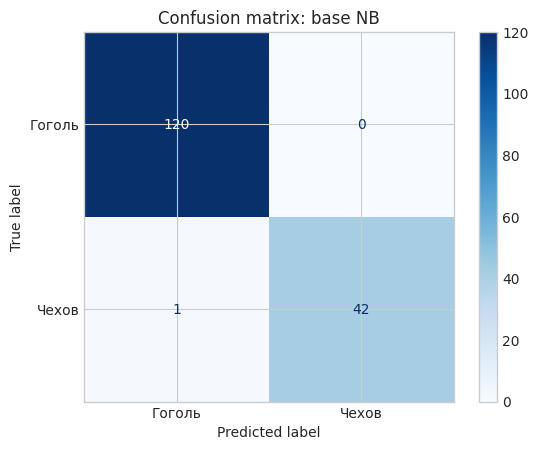

In [14]:
X = []
y = []

for text, author in [(chekhov_prose, 'Чехов'), (gogol_prose, 'Гоголь')]:
    chunks = chunk_text(text, chunk_size=160)
    X.extend(chunks)
    y.extend([author] * len(chunks))

print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

nb_base = fit_nb(X_train, y_train, X_test, y_test, alpha=1.0, min_df=2)

print('Classification report: base model')
print(classification_report(y_test, nb_base['y_pred'], digits=3))

ConfusionMatrixDisplay(nb_base['cm'], display_labels=nb_base['clf'].classes_).plot(cmap='Blues')
plt.title('Confusion matrix: base NB')
plt.show()


In [15]:
base_chekhov, base_gogol = important_tokens(nb_base, positive_class='Чехов', top_n=20)

print('Top-20 токенов в сторону Чехова по Δ(w):')
display(base_chekhov)
print('Top-20 токенов в сторону Гоголя по Δ(w):')
display(base_gogol)


Top-20 токенов в сторону Чехова по Δ(w):


,token,delta
0,егорушка,5.690412
1,христофор,4.804199
2,пантелей,4.707035
3,кузьмичов,4.398734
4,дымов,4.370563
5,егорушку,4.182511
6,иваныч,4.182511
7,мойсей,4.147420
8,вася,4.111052
9,дениска,4.111052


Top-20 токенов в сторону Гоголя по Δ(w):


,token,delta
0,чичиков,-4.783207
1,ноздрев,-3.650693
2,более,-3.327920
3,собакевич,-3.192118
4,словом,-3.155077
5,весьма,-3.096808
6,просто,-2.886087
7,чичикова,-2.873664
8,совершенно,-2.768304
9,манилов,-2.711145


Classification report: lemmatization + stopwords + ngrams
              precision    recall  f1-score   support

      Гоголь      1.000     1.000     1.000       120
       Чехов      1.000     1.000     1.000        43

    accuracy                          1.000       163
   macro avg      1.000     1.000     1.000       163
weighted avg      1.000     1.000     1.000       163



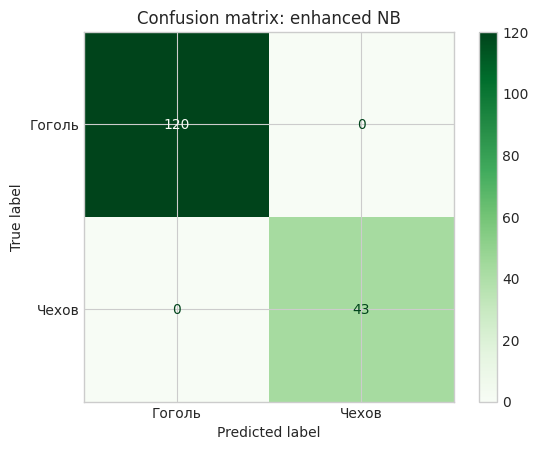

Top-20 после улучшенной предобработки: Чехов


,token,delta
0,егорушка,7.967569
1,христофор,6.920549
2,пантелей,6.774073
3,кузьмич,6.234674
4,варламов,6.100453
5,дениск,6.100453
6,вася,6.089341
7,мойсей,6.055247
8,мойсеевич,6.031854
9,емельян,5.983360


Top-20 после улучшенной предобработки: Гоголь


,token,delta
0,чичиков,-6.702441
1,ноздрево,-5.551670
2,собакевич,-5.330493
3,манилов,-4.900163
4,селифан,-4.805155
5,герой,-4.791777
6,весьма,-4.778217
7,род,-4.631434
8,председатель,-4.607433
9,читатель,-4.574508


In [16]:
nb_enhanced = fit_nb(
    X_train,
    y_train,
    X_test,
    y_test,
    preprocessor=lambda text: preprocess_tokens(text, lemmatize=True, drop_stopwords=True, ngram_range=(1, 2)),
    alpha=0.5,
    min_df=2,
)

print('Classification report: lemmatization + stopwords + ngrams')
print(classification_report(y_test, nb_enhanced['y_pred'], digits=3))

ConfusionMatrixDisplay(nb_enhanced['cm'], display_labels=nb_enhanced['clf'].classes_).plot(cmap='Greens')
plt.title('Confusion matrix: enhanced NB')
plt.show()

enh_chekhov, enh_gogol = important_tokens(nb_enhanced, positive_class='Чехов', top_n=20)

print('Top-20 после улучшенной предобработки: Чехов')
display(enh_chekhov)
print('Top-20 после улучшенной предобработки: Гоголь')
display(enh_gogol)


Domain shift report: base model (prose -> play)
              precision    recall  f1-score   support

      Гоголь      0.639     1.000     0.780       131
       Чехов      1.000     0.051     0.098        78

    accuracy                          0.646       209
   macro avg      0.820     0.526     0.439       209
weighted avg      0.774     0.646     0.525       209



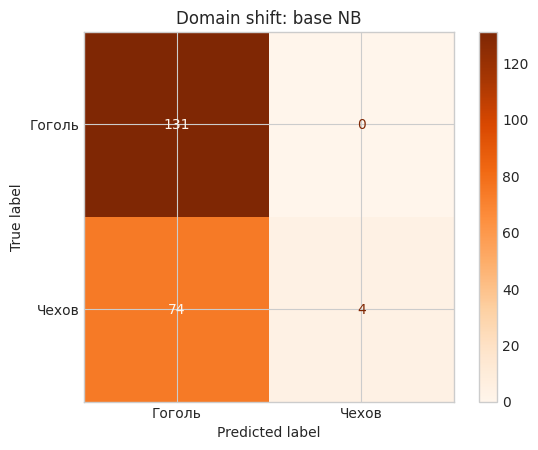

Domain shift report: enhanced model (prose -> play)
              precision    recall  f1-score   support

      Гоголь      0.697     1.000     0.821       131
       Чехов      1.000     0.269     0.424        78

    accuracy                          0.727       209
   macro avg      0.848     0.635     0.623       209
weighted avg      0.810     0.727     0.673       209



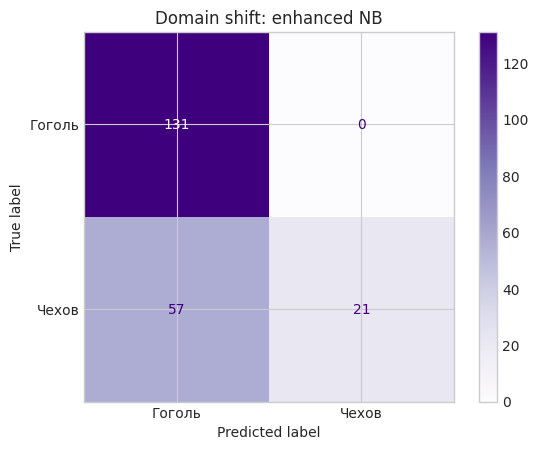

,setup,accuracy,macro_f1
0,base / in-domain,0.993865,0.992043
1,enhanced / in-domain,1.000000,1.000000
2,base / domain shift,0.645933,0.438661
3,enhanced / domain shift,0.727273,0.622780


In [17]:
X_shift = chunk_text(chekhov_play, chunk_size=160) + chunk_text(gogol_play, chunk_size=160)
y_shift = ['Чехов'] * len(chunk_text(chekhov_play, chunk_size=160)) + ['Гоголь'] * len(chunk_text(gogol_play, chunk_size=160))

base_shift_pred = nb_base['clf'].predict(nb_base['vectorizer'].transform(X_shift))
enh_shift_input = [' '.join(preprocess_tokens(text, lemmatize=True, drop_stopwords=True, ngram_range=(1, 2))) for text in X_shift]
enh_shift_pred = nb_enhanced['clf'].predict(nb_enhanced['vectorizer'].transform(enh_shift_input))

print('Domain shift report: base model (prose -> play)')
print(classification_report(y_shift, base_shift_pred, digits=3))
ConfusionMatrixDisplay(
    confusion_matrix(y_shift, base_shift_pred, labels=nb_base['clf'].classes_),
    display_labels=nb_base['clf'].classes_,
).plot(cmap='Oranges')
plt.title('Domain shift: base NB')
plt.show()

print('Domain shift report: enhanced model (prose -> play)')
print(classification_report(y_shift, enh_shift_pred, digits=3))
ConfusionMatrixDisplay(
    confusion_matrix(y_shift, enh_shift_pred, labels=nb_enhanced['clf'].classes_),
    display_labels=nb_enhanced['clf'].classes_,
).plot(cmap='Purples')
plt.title('Domain shift: enhanced NB')
plt.show()

comparison = pd.DataFrame([
    {'setup': 'base / in-domain', 'accuracy': nb_base['report']['accuracy'], 'macro_f1': nb_base['report']['macro avg']['f1-score']},
    {'setup': 'enhanced / in-domain', 'accuracy': nb_enhanced['report']['accuracy'], 'macro_f1': nb_enhanced['report']['macro avg']['f1-score']},
    {'setup': 'base / domain shift', 'accuracy': (np.array(y_shift) == base_shift_pred).mean(), 'macro_f1': classification_report(y_shift, base_shift_pred, output_dict=True)['macro avg']['f1-score']},
    {'setup': 'enhanced / domain shift', 'accuracy': (np.array(y_shift) == enh_shift_pred).mean(), 'macro_f1': classification_report(y_shift, enh_shift_pred, output_dict=True)['macro avg']['f1-score']},
])

display(comparison)


### Часть B. Эксперимент: убрать имена собственные или заменить на токен `ИМЯ`

Ниже проверим гипотезу, что модель слишком сильно опирается на имена персонажей и фамилии. Сравниваются три режима:
- `keep`: ничего не делаем с именами;
- `drop`: удаляем токены, которые `pymorphy3` считает именем/фамилией/отчеством;
- `mask`: заменяем такие токены на специальный токен `ИМЯ`.


In [19]:
NAME_GRAMMEMES = {'Name', 'Surn', 'Patr'}

EXTRA_NAME_FORMS = {
    'егорушка', 'егорушку', 'егорушке',
    'кирюха', 'кирюху', 'кирюхе',
    'дениска', 'дениску', 'дениске',
    'степка', 'степку', 'степке',
    'вася', 'васю', 'васе',
    'пантелей', 'пантелея', 'пантелею',
    'христофор', 'христофора', 'христофору',
    'емельян', 'емельяна', 'емельяну',
    'кузьмич', 'кузьмича', 'кузьмичу',
    'мойсей', 'мойсея', 'мойсею', 'мойсеич', 'мойсеича', 'мойсеичу',
    'чичиков', 'чичикова', 'чичикову',
    'манилов', 'манилова', 'манилову',
    'собакевич', 'собакевича', 'собакевичу',
    'ноздрев', 'ноздрева', 'ноздреву',
    'плюшкин', 'плюшкина', 'плюшкину',
    'селифан', 'селифана', 'селифану',
    'варламов', 'варламова', 'варламову',
    'соломон', 'соломона', 'соломону',
}

@lru_cache(maxsize=200_000)
def is_name_like(token: str) -> bool:
    token = token.lower()
    if token in EXTRA_NAME_FORMS:
        return True
    parses = morph.parse(token)
    return any(bool(NAME_GRAMMEMES & parse.tag.grammemes) for parse in parses)

def preprocess_tokens_with_names(text: str, *, name_mode='keep', lemmatize=True, drop_stopwords=True, ngram_range=(1, 2), mask_token='ИМЯ'):
    tokens = []
    for raw_token in word_tokens(text):
        token = raw_token
        if is_name_like(raw_token):
            if name_mode == 'drop':
                continue
            if name_mode == 'mask':
                token = mask_token
            elif lemmatize:
                token = lemma(raw_token)
        elif lemmatize:
            token = lemma(raw_token)

        if drop_stopwords and token != mask_token and token in RU_STOPWORDS:
            continue
        tokens.append(token)

    features = list(tokens)
    for n in range(max(2, ngram_range[0]), ngram_range[1] + 1):
        features.extend([' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
    return features

def evaluate_name_mode(name_mode: str, label: str):
    model = fit_nb(
        X_train,
        y_train,
        X_test,
        y_test,
        preprocessor=lambda text: preprocess_tokens_with_names(text, name_mode=name_mode, lemmatize=True, drop_stopwords=True, ngram_range=(1, 2)),
        alpha=0.5,
        min_df=2,
    )

    X_shift_mode = [
        ' '.join(preprocess_tokens_with_names(text, name_mode=name_mode, lemmatize=True, drop_stopwords=True, ngram_range=(1, 2)))
        for text in X_shift
    ]
    shift_pred = model['clf'].predict(model['vectorizer'].transform(X_shift_mode))
    shift_report = classification_report(y_shift, shift_pred, output_dict=True)
    top_pos, top_neg = important_tokens(model, positive_class='Чехов', top_n=15)

    return {
        'label': label,
        'model': model,
        'shift_pred': shift_pred,
        'shift_report': shift_report,
        'top_chekhov': top_pos,
        'top_gogol': top_neg,
    }

name_experiments = [
    evaluate_name_mode('keep', 'keep names'),
    evaluate_name_mode('drop', 'drop names'),
    evaluate_name_mode('mask', 'mask names -> ИМЯ'),
]

name_comparison = pd.DataFrame([
    {
        'setup': exp['label'],
        'in_domain_accuracy': exp['model']['report']['accuracy'],
        'in_domain_macro_f1': exp['model']['report']['macro avg']['f1-score'],
        'shift_accuracy': (np.array(y_shift) == exp['shift_pred']).mean(),
        'shift_macro_f1': exp['shift_report']['macro avg']['f1-score'],
        'shift_chekhov_recall': exp['shift_report']['Чехов']['recall'],
        'shift_gogol_recall': exp['shift_report']['Гоголь']['recall'],
    }
    for exp in name_experiments
])

display(name_comparison)

for exp in name_experiments:
    print(f"\n=== {exp['label']} ===")
    print('In-domain report:')
    print(classification_report(y_test, exp['model']['y_pred'], digits=3))
    print('Domain shift report:')
    print(classification_report(y_shift, exp['shift_pred'], digits=3))
    print('Top-15 в сторону Чехова:')
    display(exp['top_chekhov'])
    print('Top-15 в сторону Гоголя:')
    display(exp['top_gogol'])


,setup,in_domain_accuracy,in_domain_macro_f1,shift_accuracy,shift_macro_f1,shift_chekhov_recall,shift_gogol_recall
0,keep names,1.0,1.0,0.727273,0.622780,0.269231,1.0
1,drop names,1.0,1.0,0.736842,0.640972,0.294872,1.0
2,mask names -> ИМЯ,1.0,1.0,0.760766,0.684023,0.358974,1.0



=== keep names ===
In-domain report:
              precision    recall  f1-score   support

      Гоголь      1.000     1.000     1.000       120
       Чехов      1.000     1.000     1.000        43

    accuracy                          1.000       163
   macro avg      1.000     1.000     1.000       163
weighted avg      1.000     1.000     1.000       163

Domain shift report:
              precision    recall  f1-score   support

      Гоголь      0.697     1.000     0.821       131
       Чехов      1.000     0.269     0.424        78

    accuracy                          0.727       209
   macro avg      0.848     0.635     0.623       209
weighted avg      0.810     0.727     0.673       209

Top-15 в сторону Чехова:


,token,delta
0,егорушка,7.967569
1,христофор,6.920549
2,пантелей,6.774073
3,кузьмич,6.234674
4,варламов,6.100453
5,дениск,6.100453
6,вася,6.089341
7,мойсей,6.055247
8,мойсеевич,6.031854
9,емельян,5.983360


Top-15 в сторону Гоголя:


,token,delta
0,чичиков,-6.702441
1,ноздрево,-5.551670
2,собакевич,-5.330493
3,манилов,-4.900163
4,селифан,-4.805155
5,герой,-4.791777
6,весьма,-4.778217
7,род,-4.631434
8,председатель,-4.607433
9,читатель,-4.574508


...

,token,delta
0,весьма,-4.741328
1,председатель,-4.570544
2,читатель,-4.537619
3,глава,-4.512194
4,помещик,-4.468327
5,крестьянин,-4.344359
6,мера,-4.313429
7,ибо,-4.292264
8,правда,-4.191054
9,причина,-4.154906



=== mask names -> ИМЯ ===
In-domain report:
              precision    recall  f1-score   support

      Гоголь      1.000     1.000     1.000       120
       Чехов      1.000     1.000     1.000        43

    accuracy                          1.000       163
   macro avg      1.000     1.000     1.000       163
weighted avg      1.000     1.000     1.000       163

Domain shift report:
              precision    recall  f1-score   support

      Гоголь      0.724     1.000     0.840       131
       Чехов      1.000     0.359     0.528        78

    accuracy                          0.761       209
   macro avg      0.862     0.679     0.684       209
weighted avg      0.827     0.761     0.724       209

Top-15 в сторону Чехова:


,token,delta
0,холм,5.803025
1,воз,5.640064
2,костёр,5.547405
3,вернуться,5.547405
4,крикнуть,5.487387
5,подводчик,5.487387
6,тюк,5.466553
7,ложка,5.423536
8,плакать,5.423536
9,егорушка,5.282124


Top-15 в сторону Гоголя:


,token,delta
0,весьма,-4.767496
1,председатель,-4.596712
2,читатель,-4.563787
3,глава,-4.538362
4,помещик,-4.494495
5,крестьянин,-4.370527
6,мера,-4.339597
7,ибо,-4.318432
8,правда,-4.217222
9,причина,-4.181074


### Что ожидать от эксперимента с именами

Обычно здесь происходит одно из двух:
1. На `in-domain` качестве удаление имен немного ухудшает метрики, потому что модель теряет очень сильные сюжетные маркеры вроде `чичиков` или `егорушка`.
2. На `domain shift` качество иногда становится стабильнее, потому что модель меньше привязана к конкретному набору персонажей и чуть больше опирается на стиль, синтаксис и служебную лексику.
3. Режим `mask` часто оказывается полезнее, чем `drop`: он сохраняет информацию о том, что в позиции было имя собственное, но убирает идентичность конкретного персонажа.


### Наблюдения по части B

1. На обычном разбиении `train/test` внутри прозы наивный Байес работает почти идеально. Это нормальный результат для задачи авторства на одном жанре: модель ловит именованные сущности, устойчивые словоформы и локальные речевые привычки.
2. Важные токены у базовой модели во многом связаны с конкретными произведениями: у Чехова всплывают `егорушка`, `пантелей`, `христофор`, а у Гоголя — `чичиков`, `манилов`, `собакевич`. То есть модель частично учится не столько автору, сколько содержанию текста.
3. После лемматизации и добавления биграмм метрики на in-domain разбиении не падают, а списки важных признаков становятся компактнее и чуть лучше читаются. Но это не отменяет утечки жанра и сюжета в признаки.
4. Domain shift `проза -> пьеса` ломает модель сильно: базовый NB начинает почти всегда выбирать Гоголя, а recall по Чехову резко проседает. Главная причина в том, что пьесы сильно отличаются по форме: реплики, имена персонажей, ремарки, короткие обмены фразами.
5. Улучшенная предобработка помогает частично: macro-F1 на shift у меня вырос примерно с **0.44** до **0.62**, а recall по Чехову заметно улучшился. Видимо, леммы и биграммы слегка снижают зависимость от конкретных словоформ прозы.
6. Но полностью проблема не исчезает: если обучаться на одном жанре, модель переносится на другой жанр плохо. Для устойчивой авторской атрибуции нужны либо смешанные жанры в обучении, либо признаки, менее завязанные на сюжет и формат текста.
